The data in this project is a compilation of the monthly **output** of crude oil and condensate liquid from the major oil terminals/streams in Nigeria between January 2024 and June 2026.

The data was initially intended to be a compilation of crude oil production by field across Nigeria, however, gaining access to field-level data requires a paid license, but the terminal-level data has been made publicly available by the NUPRC.

This project is built to answer three questions:
1) To what degree does volatility exist in the output of each terminal on a month to month basis?
2) Does each terminal show a downward, upward or stable trend in output over the course of the 2.5 years, and how much does this vary from terminal to terminal?
3) Do the top 20% of the terminals in the dataset account for 80% of the total output in compliance with the "Pareto principle"?

In [79]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [80]:
df_2024 = pd.read_csv("../data/raw/NUPRC_2024_production_raw.csv")
df_2025 = pd.read_csv("../data/raw/NUPRC_2025_production_raw.csv")
df_2026 = pd.read_csv("../data/raw/NUPRC_2026_production_raw.csv")

In [81]:
df_2024.head()

,Terminal/Stream,Liquid Type,January,February,March,April,May,June,July,August,September,October,November,December
0,BONNY,Crude Oil,6351778.0,4604102.0,4260566.0,4158173.0,3605864.0,4536573.0,4584388.0,4894497.0,5589773.0,5765964.0,7051541.0,7274190.0
1,BONNY,Condensate,587495.0,583490.0,627057.0,543214.0,640026.0,568474.0,564610.0,584706.0,511021.0,494915.0,501329.0,509570.0
2,BONNY,Blend Total,6939273.0,5187592.0,4887623.0,4701387.0,4245890.0,5105047.0,5148998.0,5479203.0,6100794.0,6260879.0,7552870.0,7783759.0
3,BRASS,Crude Oil,735680.0,617189.0,686188.0,647053.0,635929.0,648849.0,664387.0,718104.0,842900.0,850352.0,775490.0,905544.0
4,BRASS,Condensate,160901.0,135498.0,158529.0,140724.0,153167.0,144677.0,148961.0,161633.0,201979.0,201451.0,179148.0,180417.0


In [82]:
df_2025.head()

,Terminal/Stream,Liquid Type,January,February,March,April,May,June,July,August,September,October,November,December
0,BONNY,Crude Oil,7570173.0,5892185.0,7360738.0,7079233.0,6673050.0,6625912.0,7567542.0,5850190.0,5924385.0,7535315.0,7751499.0,7884015.0
1,BONNY,Condensate,574015.0,475882.0,290820.0,326253.0,423241.0,542024.0,507637.0,418278.0,393815.0,399509.0,419547.0,406781.0
2,BONNY,Blend Total,8144187.0,6368067.0,7651558.0,7405486.0,7096291.0,7167936.0,8075179.0,6268468.0,6318200.0,7934823.0,8171046.0,8290796.0
3,BRASS,Crude Oil,860312.0,726912.0,937437.0,619261.0,857711.0,710231.0,820821.0,846393.0,935010.0,946439.0,981254.0,914165.0
4,BRASS,Condensate,190629.0,149116.0,180191.0,127826.0,175028.0,167744.0,294502.0,309192.0,217677.0,220768.0,225872.0,265032.0


In [83]:
df_2026.head()

,Terminal/Stream,Liquid Type,January,February,March,April,May,June
0,BONNY,Crude Oil,232.30,262.88,258.00,278.68,277.04,301.93
1,BONNY,Condensate,12.57,13.18,13.78,16.43,16.83,16.34
2,BONNY,Blend Total,244.87,276.05,271.77,295.10,293.88,318.28
3,BRASS,Crude Oil,30.36,34.41,35.09,32.99,33.77,33.18
4,BRASS,Condensate,9.51,10.04,9.37,8.52,9.77,8.67


The values in the 2026 dataset are significantly lower than those of 2025 and 2024. This is because it is measured in thousand barells per day, unlike the data in 2024 and 2025 which is measured as the total number of barells produced. The unit conversion would be done in the cleaning phase.

In [84]:
print(df_2024.shape)
print(df_2025.shape)
print(df_2026.shape)

(56, 14)
(56, 14)
(54, 8)


In [85]:
# Confirms uniformity in Terminal names across datasets 2024 and 2025
df_2024.loc[:, "Terminal/Stream"] == df_2025.loc[:, "Terminal/Stream"]

0      True
1      True
2      True
3      True
4      True
5      True
6      True
7      True
8      True
9      True
10     True
11     True
12     True
13     True
14     True
15     True
16     True
17     True
18     True
19     True
20     True
21     True
22     True
23     True
24     True
25     True
26    False
27     True
28     True
29     True
30     True
31     True
32     True
33     True
34     True
35     True
36     True
37     True
38    False
39     True
40     True
41     True
42     True
43     True
44     True
45     True
46     True
47     True
48     True
49     True
50     True
51     True
52     True
53     True
54     True
55     True
Name: Terminal/Stream, dtype: bool

In [86]:
# Extracts the names of the different Terminals identified from the previous code
print(f"2024 Index 26 name: {df_2024.iloc[26, 0]}, 2025 Index 26 name: {df_2025.iloc[26, 0]}")
print(f"2024 Index 38 name: {df_2024.iloc[38, 0]}, 2025 Index 38 name: {df_2025.iloc[38, 0]}")

2024 Index 26 name: OTAKPIPO (Ex Ima Terminal), 2025 Index 26 name: OTAKPIPO
2024 Index 38 name: OYO, 2025 Index 38 name: OYO / OBODO


Comparing terminal names between 2024 and 2025: two mismatches found — 'OTAKPIPO (Ex Ima Terminal)' (2024) vs 'OTAKPIPO' (2025), and 'OYO' (2024) vs 'OYO / OBODO' (2025, likely reflecting a new grade addition). Same entity in both cases. Will standardize in cleaning, once I've checked whether 2026 introduces further variants.

In [87]:
#create a list of the Terminals/Streams in 2025 dataset
terminal_list_2025 = list(df_2025["Terminal/Stream"])
#create a list of the Terminals/Streams in 2026 dataset
terminal_list_2026 = list(df_2026["Terminal/Stream"])

#check which Terminals were removed from 2025 in 2026
removed_from_2025 = [terminal for terminal in terminal_list_2025 if terminal not in terminal_list_2026]
#check which Terminals were added in 2026 that were not in 2025
added_in_2026 = [terminal for terminal in terminal_list_2026 if terminal not in terminal_list_2025]
print(f"Terminals/Streams removed from 2025 in 2026: {removed_from_2025}")
print(f"Terminals/Streams added in 2026: {added_in_2026}")


Terminals/Streams removed from 2025 in 2026: ['ASARAMATORU (Ex Ima Terminal)', 'ANAMBRA BASIN', 'UKPOKITI']
Terminals/Streams added in 2026: ['CAWTHORNE']


As seen from the shape of the three datasets, data from the year 2026 has 2 fewer records(rows) than those of 2025 and 2024, as well as 6 fewer fields(columns).
The difference in fields is due to the fact that the 2026 entries end at June 2026.
THe difference in records, is caused by the removal of three Terminals from 2025 (ASARAMATORU (Ex Ima Terminal), ANAMBRA BASIN, UKPOKITI) and the addition of one in 2026 (CAWTHORNE).

In [88]:
df_2024.dtypes

Terminal/Stream        str
Liquid Type            str
January            float64
February           float64
March              float64
April              float64
May                float64
June               float64
July               float64
August             float64
September          float64
October            float64
November           float64
December           float64
dtype: object

In [89]:
df_2025.dtypes

Terminal/Stream        str
Liquid Type            str
January            float64
February           float64
March              float64
April              float64
May                float64
June               float64
July               float64
August             float64
September          float64
October            float64
November           float64
December           float64
dtype: object

In [90]:
df_2026.dtypes

Terminal/Stream        str
Liquid Type            str
January            float64
February           float64
March              float64
April              float64
May                float64
June               float64
dtype: object

Data types for each field are consistent with what is expected across the datasets.

In [91]:
null_2024_values = df_2024[df_2024[["January", "February", "March", "April", "May", "June", "July", "August", "September", "October", "November", "December"]].isnull().all(axis=1)]
null_2024_values

,Terminal/Stream,Liquid Type,January,February,March,April,May,June,July,August,September,October,November,December
19,TULJA - OKWUIBOME,Condensate,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
21,AJE,Crude Oil,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
22,AJE,Condensate,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
23,AJE,Blend Total,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25,ASARAMATORU (Ex Ima Terminal),Crude Oil,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
33,ANAMBRA BASIN,Crude Oil,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
41,UKPOKITI,Crude Oil,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
49,IMA,Condensate,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [92]:
null_2025_values = df_2025[df_2025[["January", "February", "March", "April", "May", "June", "July", "August", "September", "October", "November", "December"]].isnull().all(axis=1)]
null_2025_values

,Terminal/Stream,Liquid Type,January,February,March,April,May,June,July,August,September,October,November,December
19,TULJA - OKWUIBOME,Condensate,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
21,AJE,Crude Oil,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
22,AJE,Condensate,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
23,AJE,Blend Total,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25,ASARAMATORU (Ex Ima Terminal),Crude Oil,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
33,ANAMBRA BASIN,Crude Oil,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
41,UKPOKITI,Crude Oil,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
49,IMA,Condensate,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [93]:
null_2026_values = df_2026[df_2026[["January", "February", "March", "April", "May", "June"]].isnull().all(axis=1)]
null_2026_values

,Terminal/Stream,Liquid Type,January,February,March,April,May,June
19,TULJA - OKWUIBOME,Condensate,NaN,NaN,NaN,NaN,NaN,NaN
21,AJE,Crude Oil,NaN,NaN,NaN,NaN,NaN,NaN
22,AJE,Condensate,NaN,NaN,NaN,NaN,NaN,NaN
23,AJE,Blend Total,NaN,NaN,NaN,NaN,NaN,NaN
47,IMA,Condensate,NaN,NaN,NaN,NaN,NaN,NaN


It can be seen that some records in each dataset are entirely empty.
Any records with completely missing values would be dropped during analysis in cleaning.

In [94]:
duplicates_2024 = df_2024[df_2024.duplicated(subset=["Terminal/Stream", "Liquid Type"], keep=False)]
duplicates_2024

,Terminal/Stream,Liquid Type,January,February,March,April,May,June,July,August,September,October,November,December
19,TULJA - OKWUIBOME,Condensate,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
51,TULJA - OKWUIBOME,Condensate,284045.0,264581.0,304064.0,299673.0,308497.0,280251.0,301720.0,283275.0,255131.0,296237.0,288743.0,282139.0


In [95]:
duplicates_2025 = df_2025[df_2025.duplicated(subset=["Terminal/Stream", "Liquid Type"], keep=False)]
duplicates_2025

,Terminal/Stream,Liquid Type,January,February,March,April,May,June,July,August,September,October,November,December
19,TULJA - OKWUIBOME,Condensate,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
51,TULJA - OKWUIBOME,Condensate,254417.0,272591.0,280584.0,267405.0,284381.0,276006.0,296915.0,303162.0,302246.0,320364.0,310201.0,318711.0


In [96]:
duplicates_2026 = df_2026[df_2026.duplicated(subset=["Terminal/Stream", "Liquid Type"], keep=False)]
duplicates_2026

,Terminal/Stream,Liquid Type,January,February,March,April,May,June
19,TULJA - OKWUIBOME,Condensate,NaN,NaN,NaN,NaN,NaN,NaN
49,TULJA - OKWUIBOME,Condensate,10.27,10.22,10.22,10.16,10.15,10.11


Seems to be a duplicate for the record of "TULJA - OKWUIBOME" Terminal in 2024, 2025 and 2026 datasets. However, one of the entries is entirely null, so it would be discarded, and the entry with values would be used during analysis.

In [97]:
df_2024.describe()

,January,February,March,April,May,June,July,August,September,October,November,December
count,4.700000e+01,4.600000e+01,4.500000e+01,4.500000e+01,4.800000e+01,4.800000e+01,4.700000e+01,4.600000e+01,4.700000e+01,4.800000e+01,4.700000e+01,4.600000e+01
mean,3.886803e+06,3.464650e+06,3.558266e+06,3.459646e+06,3.364831e+06,3.333609e+06,3.587569e+06,3.767743e+06,3.511816e+06,3.513831e+06,3.873075e+06,4.018648e+06
std,9.598539e+06,8.439076e+06,8.487552e+06,8.387670e+06,8.388354e+06,8.297007e+06,8.857906e+06,9.219967e+06,8.656225e+06,8.843177e+06,9.612682e+06,9.940376e+06
min,6.413000e+03,4.265000e+03,6.954000e+03,6.427000e+03,3.896000e+03,6.970000e+03,6.789000e+03,5.246000e+03,5.821000e+03,6.910000e+02,5.462000e+03,5.498000e+03
25%,3.136330e+05,2.756445e+05,3.218740e+05,2.996730e+05,3.091998e+05,3.145505e+05,3.139880e+05,3.040902e+05,2.701315e+05,3.159208e+05,2.880235e+05,2.924245e+05
50%,9.453010e+05,1.036540e+06,1.061497e+06,8.892320e+05,8.322980e+05,8.149315e+05,9.281170e+05,9.379035e+05,1.044879e+06,1.108908e+06,9.546380e+05,1.185612e+06
75%,3.344956e+06,3.410196e+06,3.006372e+06,3.306128e+06,2.884685e+06,2.891586e+06,3.108878e+06,2.977762e+06,2.795426e+06,2.991664e+06,3.316910e+06,3.468504e+06
max,5.095380e+07,4.464866e+07,4.458200e+07,4.342305e+07,4.552568e+07,4.500597e+07,4.754465e+07,4.869112e+07,4.632869e+07,4.768198e+07,5.071454e+07,5.169436e+07


In [98]:
df_2025.describe()

,January,February,March,April,May,June,July,August,September,October,November,December
count,4.700000e+01,4.700000e+01,4.700000e+01,4.700000e+01,4.700000e+01,4.700000e+01,4.700000e+01,4.600000e+01,4.700000e+01,4.600000e+01,4.700000e+01,4.700000e+01
mean,4.113849e+06,3.565249e+06,3.767954e+06,3.868917e+06,3.912937e+06,3.893134e+06,4.057606e+06,3.939309e+06,3.614519e+06,3.867868e+06,3.703512e+06,3.728139e+06
std,1.023145e+07,8.844670e+06,9.364226e+06,9.607048e+06,9.703991e+06,9.684700e+06,1.006551e+07,9.664645e+06,8.971540e+06,9.501998e+06,9.225472e+06,9.337117e+06
min,5.934000e+03,4.508000e+03,5.221000e+03,4.865000e+03,5.043000e+03,4.438000e+03,4.741000e+03,4.741000e+03,4.590000e+03,4.666000e+03,4.565000e+03,4.616000e+03
25%,3.747460e+05,3.035360e+05,2.834890e+05,3.009920e+05,3.188700e+05,2.782285e+05,3.056510e+05,3.266940e+05,2.950640e+05,2.970438e+05,2.631515e+05,2.369545e+05
50%,1.050941e+06,1.080581e+06,1.145283e+06,1.051648e+06,1.178584e+06,1.161601e+06,1.189629e+06,1.251420e+06,1.152687e+06,1.294378e+06,1.212574e+06,1.119722e+06
75%,3.173460e+06,3.011052e+06,3.012108e+06,3.067994e+06,3.152703e+06,2.886904e+06,3.100470e+06,3.232327e+06,2.791990e+06,2.627290e+06,2.492530e+06,2.118758e+06
max,5.386188e+07,4.681470e+07,4.971706e+07,5.049921e+07,5.138048e+07,5.091136e+07,5.308074e+07,5.058000e+07,4.743544e+07,4.951318e+07,4.797161e+07,4.787469e+07


In [99]:
df_2026.describe()

,January,February,March,April,May,June
count,48.000000,47.000000,47.000000,48.000000,47.000000,47.000000
mean,121.997708,115.479362,118.110213,124.798750,130.962128,133.871064
std,308.584827,283.550812,294.975139,315.283581,326.805024,333.549098
min,0.120000,0.770000,0.780000,0.000000,0.090000,0.330000
25%,8.587500,8.435000,8.380000,7.795000,7.220000,7.355000
50%,40.450000,36.320000,41.570000,40.555000,41.720000,40.680000
75%,82.162500,67.165000,81.285000,76.657500,86.135000,88.860000
max,1627.460000,1483.950000,1546.090000,1663.410000,1700.800000,1735.400000


Significantly lower values in the description of the 2026 dataset is expected, as it was recorded in a different unit (thousand barrels per month). Conversion would be done in the cleaning phase.

In [100]:
df_2024.columns == df_2025.columns

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True])

In [101]:
df_2025.columns[0:8] == df_2026.columns

array([ True,  True,  True,  True,  True,  True,  True,  True])

In [102]:
df_2024_cleaned = df_2024.drop(null_2024_values.index)
df_2025_cleaned = df_2025.drop(null_2025_values.index)
df_2026_cleaned = df_2026.drop(null_2026_values.index)

In [103]:
# Changing units of data in df_2026 from thousand_barrels_per_month to barrels_per_month
days_per_month = {
    "January": 31,
    "February": 28,
    "March": 31,
    "April": 30,
    "May": 31,
    "June": 30,
}

months = list(df_2026_cleaned.columns[2:])

for index, month in enumerate(months):
    df_2026_cleaned[month] = df_2026_cleaned.iloc[:, 2+index] * 1000 * days_per_month[month]
df_2026_cleaned


,Terminal/Stream,Liquid Type,January,February,March,April,May,June
0,BONNY,Crude Oil,7201300.0,7360640.0,7998000.0,8360400.0,8588240.0,9057900.0
1,BONNY,Condensate,389670.0,369040.0,427180.0,492900.0,521730.0,490200.0
2,BONNY,Blend Total,7590970.0,7729400.0,8424870.0,8853000.0,9110280.0,9548400.0
3,BRASS,Crude Oil,941160.0,963480.0,1087790.0,989700.0,1046870.0,995400.0
4,BRASS,Condensate,294810.0,281120.0,290470.0,255600.0,302870.0,260100.0
5,BRASS,Blend Total,1235970.0,1244600.0,1378260.0,1245000.0,1349740.0,1255500.0
6,QUA IBOE,Crude Oil,4549870.0,4401040.0,5196840.0,4918200.0,5371370.0,4892100.0
7,QUA IBOE,Condensate,57040.0,43680.0,49600.0,46800.0,2790.0,49500.0
8,QUA IBOE,Blend Total,4606910.0,4445000.0,5246440.0,4965000.0,5374160.0,4941600.0
9,FORCADOS,Crude Oil,7946850.0,6234760.0,4733080.0,6654000.0,8265530.0,8485800.0


In [104]:
df_2024_cleaned = round(df_2024_cleaned, 2)
df_2025_cleaned = round(df_2025_cleaned, 2)
df_2026_cleaned = round(df_2026_cleaned, 2)

In [105]:
df_2024_cleaned["Terminal/Stream"] = df_2024_cleaned["Terminal/Stream"].replace({"OYO": "OYO / OBODO", "OTAKPIPO (Ex Ima Terminal)": "OTAKPIPO"})
df_2024_cleaned

,Terminal/Stream,Liquid Type,January,February,March,April,May,June,July,August,September,October,November,December
0,BONNY,Crude Oil,6351778.0,4604102.0,4260566.0,4158173.0,3605864.0,4536573.0,4584388.0,4894497.0,5589773.0,5765964.0,7051541.0,7274190.0
1,BONNY,Condensate,587495.0,583490.0,627057.0,543214.0,640026.0,568474.0,564610.0,584706.0,511021.0,494915.0,501329.0,509570.0
2,BONNY,Blend Total,6939273.0,5187592.0,4887623.0,4701387.0,4245890.0,5105047.0,5148998.0,5479203.0,6100794.0,6260879.0,7552870.0,7783759.0
3,BRASS,Crude Oil,735680.0,617189.0,686188.0,647053.0,635929.0,648849.0,664387.0,718104.0,842900.0,850352.0,775490.0,905544.0
4,BRASS,Condensate,160901.0,135498.0,158529.0,140724.0,153167.0,144677.0,148961.0,161633.0,201979.0,201451.0,179148.0,180417.0
5,BRASS,Blend Total,896581.0,752687.0,844717.0,787777.0,789096.0,793526.0,813348.0,879737.0,1044879.0,1051803.0,954638.0,1085961.0
6,QUA IBOE,Crude Oil,4251198.0,3664686.0,4058695.0,4284484.0,3962759.0,3261367.0,3343465.0,3073804.0,2833479.0,4114319.0,4171753.0,4132506.0
7,QUA IBOE,Condensate,45075.0,44684.0,37225.0,16091.0,3896.0,18795.0,18725.0,19933.0,18906.0,23269.0,20737.0,23315.0
8,QUA IBOE,Blend Total,4296273.0,3709370.0,4095920.0,4300575.0,3966655.0,3280162.0,3362190.0,3093737.0,2852385.0,4137588.0,4192490.0,4155821.0
9,FORCADOS,Crude Oil,7799819.0,6796892.0,6675119.0,6289085.0,5927475.0,6160694.0,6813681.0,8126915.0,6341130.0,4513085.0,7835499.0,7793585.0


In [106]:
df_2024_cleaned = df_2024_cleaned.drop(df_2024_cleaned[df_2024_cleaned["Liquid Type"] == "Condensate"].index)
df_2024_cleaned = df_2024_cleaned.drop(df_2024_cleaned[df_2024_cleaned["Liquid Type"] == "Blend Total"].index)
df_2024_cleaned = df_2024_cleaned.drop(df_2024_cleaned[df_2024_cleaned["Terminal/Stream"] == "TOTAL"].index)
df_2025_cleaned = df_2025_cleaned.drop(df_2025_cleaned[df_2025_cleaned["Liquid Type"] == "Condensate"].index)
df_2025_cleaned = df_2025_cleaned.drop(df_2025_cleaned[df_2025_cleaned["Liquid Type"] == "Blend Total"].index)
df_2025_cleaned = df_2025_cleaned.drop(df_2025_cleaned[df_2025_cleaned["Terminal/Stream"] == "TOTAL"].index)
df_2026_cleaned = df_2026_cleaned.drop(df_2026_cleaned[df_2026_cleaned["Liquid Type"] == "Condensate"].index)
df_2026_cleaned = df_2026_cleaned.drop(df_2026_cleaned[df_2026_cleaned["Liquid Type"] == "Blend Total"].index)
df_2026_cleaned = df_2026_cleaned.drop(df_2026_cleaned[df_2026_cleaned["Terminal/Stream"] == "TOTAL"].index)

In [107]:
df_2025_cleaned

,Terminal/Stream,Liquid Type,January,February,March,April,May,June,July,August,September,October,November,December
0,BONNY,Crude Oil,7570173.0,5892185.0,7360738.0,7079233.0,6673050.0,6625912.0,7567542.0,5850190.0,5924385.0,7535315.0,7751499.0,7884015.0
3,BRASS,Crude Oil,860312.0,726912.0,937437.0,619261.0,857711.0,710231.0,820821.0,846393.0,935010.0,946439.0,981254.0,914165.0
6,QUA IBOE,Crude Oil,4580997.0,4227836.0,3504376.0,4296506.0,4921690.0,5036322.0,4503690.0,4946259.0,4640056.0,2683665.0,3980764.0,5074619.0
9,FORCADOS,Crude Oil,7997419.0,6919400.0,5798465.0,8409659.0,7089537.0,7901129.0,8059799.0,8084121.0,6853852.0,8585208.0,8327198.0,8569954.0
12,ESCRAVOS (Oil Terminal),Crude Oil,4261436.0,3794400.0,4186992.0,4082589.0,4439405.0,4047894.0,4335432.0,4080954.0,4129694.0,4329068.0,3829825.0,4091466.0
15,ODUDU (AMENAM BLEND),Crude Oil,2324122.0,2063093.0,2313424.0,2106782.0,1890759.0,2061295.0,2124883.0,1846043.0,2005854.0,2111519.0,1888702.0,1970777.0
18,TULJA - OKWUIBOME,Crude Oil,2260611.0,1899107.0,2110574.0,2065631.0,2119797.0,2024726.0,2080781.0,2009287.0,1627130.0,1581339.0,1591292.0,1561674.0
24,OKORO (Ex Ima Terminal),Crude Oil,168432.0,141970.0,160308.0,158837.0,154386.0,143657.0,137526.0,72429.0,134175.0,147289.0,145562.0,163212.0
26,OTAKPIPO,Crude Oil,210114.0,125233.0,114411.0,148290.0,212252.0,220666.0,185672.0,215945.0,206713.0,204048.0,194965.0,199316.0
27,ANTAN,Crude Oil,264704.0,233546.0,257473.0,167148.0,177763.0,198236.0,161708.0,151628.0,145910.0,167509.0,29839.0,136740.0


In [108]:
df_2024_cleaned

,Terminal/Stream,Liquid Type,January,February,March,April,May,June,July,August,September,October,November,December
0,BONNY,Crude Oil,6351778.0,4604102.0,4260566.0,4158173.0,3605864.0,4536573.0,4584388.0,4894497.0,5589773.0,5765964.0,7051541.0,7274190.0
3,BRASS,Crude Oil,735680.0,617189.0,686188.0,647053.0,635929.0,648849.0,664387.0,718104.0,842900.0,850352.0,775490.0,905544.0
6,QUA IBOE,Crude Oil,4251198.0,3664686.0,4058695.0,4284484.0,3962759.0,3261367.0,3343465.0,3073804.0,2833479.0,4114319.0,4171753.0,4132506.0
9,FORCADOS,Crude Oil,7799819.0,6796892.0,6675119.0,6289085.0,5927475.0,6160694.0,6813681.0,8126915.0,6341130.0,4513085.0,7835499.0,7793585.0
12,ESCRAVOS (Oil Terminal),Crude Oil,4178516.0,3684339.0,4012721.0,3866374.0,4113862.0,3996696.0,4385991.0,4209219.0,4080483.0,4276766.0,3992925.0,3807346.0
15,ODUDU (AMENAM BLEND),Crude Oil,2934994.0,2722999.0,2836178.0,2659792.0,2630817.0,2572785.0,2468442.0,2583858.0,2462691.0,2526821.0,2423720.0,2446481.0
18,TULJA - OKWUIBOME,Crude Oil,1762863.0,1732677.0,1859018.0,1837364.0,1972551.0,1928150.0,1992021.0,2008090.0,2029787.0,2212884.0,2219874.0,2250725.0
24,OKORO (Ex Ima Terminal),Crude Oil,203761.0,190965.0,201924.0,182645.0,188990.0,167626.0,181758.0,173385.0,167614.0,177386.0,172483.0,173580.0
26,OTAKPIPO,Crude Oil,278843.0,217705.0,242882.0,270168.0,306424.0,270141.0,266605.0,197152.0,195878.0,169735.0,127545.0,186192.0
27,ANTAN,Crude Oil,348555.0,339797.0,351219.0,316850.0,347468.0,338999.0,326256.0,301795.0,282378.0,322482.0,262803.0,257832.0


In [109]:
df_2024_cleaned["Terminal/Stream"] == df_2025_cleaned["Terminal/Stream"]

0     True
3     True
6     True
9     True
12    True
15    True
18    True
24    True
26    True
27    True
28    True
29    True
30    True
31    True
32    True
34    True
35    True
36    True
37    True
38    True
39    True
40    True
42    True
43    True
44    True
45    True
46    True
Name: Terminal/Stream, dtype: bool

In [110]:
terminals_removed_from_2025 = [terminal for terminal in list(df_2025_cleaned["Terminal/Stream"]) if terminal not in list(df_2026_cleaned["Terminal/Stream"])]
terminals_added_to_2026 = [terminal for terminal in list(df_2026_cleaned["Terminal/Stream"]) if terminal not in list(df_2025_cleaned["Terminal/Stream"])]

print(f"Terminals removed from 2025 in 2026: {terminals_removed_from_2025}")
print(f"Terminals added to 2026 from 2025: {terminals_added_to_2026}")


Terminals removed from 2025 in 2026: []
Terminals added to 2026 from 2025: ['CAWTHORNE']


The exact same terminals from 2024 carried on through the cleaning process into 2025. However, in 2026, a new terminal was added: CAWTHORNE.

In [111]:
df_2024_cleaned.set_index("Terminal/Stream").to_csv("../data/cleaned/NUPRC_2024_production_cleaned.csv")
df_2025_cleaned.set_index("Terminal/Stream").to_csv("../data/cleaned/NUPRC_2025_production_cleaned.csv")
df_2026_cleaned.set_index("Terminal/Stream").to_csv("../data/cleaned/NUPRC_2026_production_cleaned.csv")

## Question 1: Output Volatility (2024–Mid 2026)
Comparing between outputs of consecutive months for each terminal. Any extreme/abnormal jumps or falls in output would be investigated.

In [112]:
q1_df_2024 = pd.read_csv("../data/cleaned/NUPRC_2024_production_cleaned.csv")
q1_df_2025 = pd.read_csv("../data/cleaned/NUPRC_2025_production_cleaned.csv")
q1_df_2026 = pd.read_csv("../data/cleaned/NUPRC_2026_production_cleaned.csv")

In [113]:
q1_df_2024.head()

,Terminal/Stream,Liquid Type,January,February,March,April,May,June,July,August,September,October,November,December
0,BONNY,Crude Oil,6351778.0,4604102.0,4260566.0,4158173.0,3605864.0,4536573.0,4584388.0,4894497.0,5589773.0,5765964.0,7051541.0,7274190.0
1,BRASS,Crude Oil,735680.0,617189.0,686188.0,647053.0,635929.0,648849.0,664387.0,718104.0,842900.0,850352.0,775490.0,905544.0
2,QUA IBOE,Crude Oil,4251198.0,3664686.0,4058695.0,4284484.0,3962759.0,3261367.0,3343465.0,3073804.0,2833479.0,4114319.0,4171753.0,4132506.0
3,FORCADOS,Crude Oil,7799819.0,6796892.0,6675119.0,6289085.0,5927475.0,6160694.0,6813681.0,8126915.0,6341130.0,4513085.0,7835499.0,7793585.0
4,ESCRAVOS (Oil Terminal),Crude Oil,4178516.0,3684339.0,4012721.0,3866374.0,4113862.0,3996696.0,4385991.0,4209219.0,4080483.0,4276766.0,3992925.0,3807346.0


In [114]:
q1_df_2025.head()

,Terminal/Stream,Liquid Type,January,February,March,April,May,June,July,August,September,October,November,December
0,BONNY,Crude Oil,7570173.0,5892185.0,7360738.0,7079233.0,6673050.0,6625912.0,7567542.0,5850190.0,5924385.0,7535315.0,7751499.0,7884015.0
1,BRASS,Crude Oil,860312.0,726912.0,937437.0,619261.0,857711.0,710231.0,820821.0,846393.0,935010.0,946439.0,981254.0,914165.0
2,QUA IBOE,Crude Oil,4580997.0,4227836.0,3504376.0,4296506.0,4921690.0,5036322.0,4503690.0,4946259.0,4640056.0,2683665.0,3980764.0,5074619.0
3,FORCADOS,Crude Oil,7997419.0,6919400.0,5798465.0,8409659.0,7089537.0,7901129.0,8059799.0,8084121.0,6853852.0,8585208.0,8327198.0,8569954.0
4,ESCRAVOS (Oil Terminal),Crude Oil,4261436.0,3794400.0,4186992.0,4082589.0,4439405.0,4047894.0,4335432.0,4080954.0,4129694.0,4329068.0,3829825.0,4091466.0


In [115]:
q1_df_2026.head()

,Terminal/Stream,Liquid Type,January,February,March,April,May,June
0,BONNY,Crude Oil,7201300.0,7360640.0,7998000.0,8360400.0,8588240.0,9057900.0
1,BRASS,Crude Oil,941160.0,963480.0,1087790.0,989700.0,1046870.0,995400.0
2,QUA IBOE,Crude Oil,4549870.0,4401040.0,5196840.0,4918200.0,5371370.0,4892100.0
3,FORCADOS,Crude Oil,7946850.0,6234760.0,4733080.0,6654000.0,8265530.0,8485800.0
4,ESCRAVOS (Oil Terminal),Crude Oil,4227470.0,3745000.0,4355500.0,4070100.0,4128890.0,4053600.0


In [116]:
months_2024 = q1_df_2024.columns[2:]
months_2025 = q1_df_2025.columns[2:]
months_2026 = q1_df_2026.columns[2:]
months_edited_2024 = [f"{month}-2024" for month in months_2024]
months_edited_2025 = [f"{month}-2025" for month in months_2025]
months_edited_2026 = [f"{month}-2026" for month in months_2026]
q1_df_2024.rename(columns=dict(zip(months_2024, months_edited_2024)), inplace=True)
q1_df_2025.rename(columns=dict(zip(months_2025, months_edited_2025)), inplace=True)
q1_df_2026.rename(columns=dict(zip(months_2026, months_edited_2026)), inplace=True)
q1_df_2024 = q1_df_2024.set_index("Terminal/Stream")
q1_df_2025 = q1_df_2025.set_index("Terminal/Stream")
q1_df_2026 = q1_df_2026.set_index("Terminal/Stream")
q1_master_df = pd.concat([q1_df_2024, q1_df_2025, q1_df_2026], axis=1)
q1_master_df = q1_master_df.loc[:, ~q1_master_df.columns.duplicated()]

q1_master_df

,Liquid Type,January-2024,February-2024,March-2024,April-2024,May-2024,June-2024,July-2024,August-2024,September-2024,...,September-2025,October-2025,November-2025,December-2025,January-2026,February-2026,March-2026,April-2026,May-2026,June-2026
Terminal/Stream,,,,,,,,,,,,,,,,,,,,,
BONNY,Crude Oil,6351778.0,4604102.0,4260566.0,4158173.0,3605864.0,4536573.0,4584388.0,4894497.0,5589773.0,...,5924385.0,7535315.0,7751499.0,7884015.0,7201300.0,7360640.0,7998000.0,8360400.0,8588240.0,9057900.0
BRASS,Crude Oil,735680.0,617189.0,686188.0,647053.0,635929.0,648849.0,664387.0,718104.0,842900.0,...,935010.0,946439.0,981254.0,914165.0,941160.0,963480.0,1087790.0,989700.0,1046870.0,995400.0
QUA IBOE,Crude Oil,4251198.0,3664686.0,4058695.0,4284484.0,3962759.0,3261367.0,3343465.0,3073804.0,2833479.0,...,4640056.0,2683665.0,3980764.0,5074619.0,4549870.0,4401040.0,5196840.0,4918200.0,5371370.0,4892100.0
FORCADOS,Crude Oil,7799819.0,6796892.0,6675119.0,6289085.0,5927475.0,6160694.0,6813681.0,8126915.0,6341130.0,...,6853852.0,8585208.0,8327198.0,8569954.0,7946850.0,6234760.0,4733080.0,6654000.0,8265530.0,8485800.0
ESCRAVOS (Oil Terminal),Crude Oil,4178516.0,3684339.0,4012721.0,3866374.0,4113862.0,3996696.0,4385991.0,4209219.0,4080483.0,...,4129694.0,4329068.0,3829825.0,4091466.0,4227470.0,3745000.0,4355500.0,4070100.0,4128890.0,4053600.0
ODUDU (AMENAM BLEND),Crude Oil,2934994.0,2722999.0,2836178.0,2659792.0,2630817.0,2572785.0,2468442.0,2583858.0,2462691.0,...,2005854.0,2111519.0,1888702.0,1970777.0,1946800.0,1862840.0,2034840.0,1854000.0,1953310.0,1859400.0
TULJA - OKWUIBOME,Crude Oil,1762863.0,1732677.0,1859018.0,1837364.0,1972551.0,1928150.0,1992021.0,2008090.0,2029787.0,...,1627130.0,1581339.0,1591292.0,1561674.0,1758010.0,1386840.0,1566740.0,1595700.0,1655710.0,1626600.0
OKORO (Ex Ima Terminal),Crude Oil,203761.0,190965.0,201924.0,182645.0,188990.0,167626.0,181758.0,173385.0,167614.0,...,134175.0,147289.0,145562.0,163212.0,154070.0,93800.0,119040.0,114000.0,119660.0,162900.0
OTAKPIPO,Crude Oil,278843.0,217705.0,242882.0,270168.0,306424.0,270141.0,266605.0,197152.0,195878.0,...,206713.0,204048.0,194965.0,199316.0,196230.0,176120.0,263190.0,255600.0,223510.0,178200.0


In [117]:
volatility_df = q1_master_df.iloc[:, 1:].pct_change(axis=1, fill_method=None) * 100
volatility_df

,January-2024,February-2024,March-2024,April-2024,May-2024,June-2024,July-2024,August-2024,September-2024,October-2024,...,September-2025,October-2025,November-2025,December-2025,January-2026,February-2026,March-2026,April-2026,May-2026,June-2026
Terminal/Stream,,,,,,,,,,,,,,,,,,,,,
BONNY,NaN,-27.514753,-7.461520,-2.403272,-13.282492,25.810985,1.053989,6.764458,14.205259,3.152024,...,1.268249,27.191514,2.868944,1.709553,-8.659484,2.212656,8.659030,4.531133,2.725228,5.468641
BRASS,NaN,-16.106323,11.179558,-5.703248,-1.719179,2.031673,2.394702,8.085197,17.378541,0.884091,...,10.469959,1.222340,3.678526,-6.837068,2.952968,2.371542,12.902188,-9.017365,5.776498,-4.916561
QUA IBOE,NaN,-13.796393,10.751508,5.563094,-7.509072,-17.699588,2.517288,-8.065315,-7.818488,45.203794,...,-6.190598,-42.163090,48.333119,27.478519,-10.340658,-3.271082,18.082090,-5.361720,9.214143,-8.922677
FORCADOS,NaN,-12.858337,-1.791598,-5.783178,-5.749803,3.934542,10.599244,19.273488,-21.973713,-28.828379,...,-15.218340,25.261065,-3.005285,2.915218,-7.270797,-21.544260,-24.085610,40.584989,24.218966,2.664923
ESCRAVOS (Oil Terminal),NaN,-11.826615,8.912915,-3.647076,6.401036,-2.848078,9.740421,-4.030378,-3.058430,4.810288,...,1.194329,4.827815,-11.532344,6.831670,3.324090,-11.412736,16.301736,-6.552635,1.444436,-1.823493
ODUDU (AMENAM BLEND),NaN,-7.223013,4.156410,-6.219144,-1.089371,-2.205855,-4.055644,4.675662,-4.689383,2.604062,...,8.656949,5.267831,-10.552451,4.345577,-1.216627,-4.312718,9.233214,-8.887185,5.356526,-4.807737
TULJA - OKWUIBOME,NaN,-1.712328,7.291665,-1.164809,7.357660,-2.250943,3.312553,0.806668,1.080479,9.020503,...,-19.019533,-2.814219,0.629403,-1.861255,12.572150,-21.113077,12.971936,1.848424,3.760732,-1.758158
OKORO (Ex Ima Terminal),NaN,-6.279906,5.738748,-9.547652,3.473952,-11.304302,8.430673,-4.606675,-3.328431,5.830062,...,85.250383,9.773803,-1.172525,12.125417,-5.601304,-39.118582,26.908316,-4.233871,4.964912,36.135718
OTAKPIPO,NaN,-21.925600,11.564732,11.234262,13.419798,-11.840783,-1.308946,-26.050899,-0.646202,-13.346573,...,-4.275163,-1.289227,-4.451404,2.231683,-1.548295,-10.248178,49.437883,-2.883848,-12.554773,-20.272024


In [118]:
deviation_df = pd.DataFrame({"Standard Deviation": volatility_df.std(axis=1)}, index=q1_master_df.index)
deviation_df

,Standard Deviation
Terminal/Stream,
BONNY,13.567211
BRASS,14.407637
QUA IBOE,18.619896
FORCADOS,22.664149
ESCRAVOS (Oil Terminal),7.937962
ODUDU (AMENAM BLEND),6.977909
TULJA - OKWUIBOME,8.039932
OKORO (Ex Ima Terminal),22.573714
OTAKPIPO,21.511523


In [119]:
sorted_deviation_df = deviation_df.sort_values(ascending=False, by="Standard Deviation")
sorted_deviation_df

,Standard Deviation
Terminal/Stream,
BONGA,918.446274
OYO / OBODO,175.965004
ERHA,100.851176
PENNINGTON,82.564655
ANTAN,69.970025
AJAPA,65.568171
USAN,59.097935
UGO OCHA (JONES CREEK),55.544122
ANYALA MADU (CJ Blend),45.835102


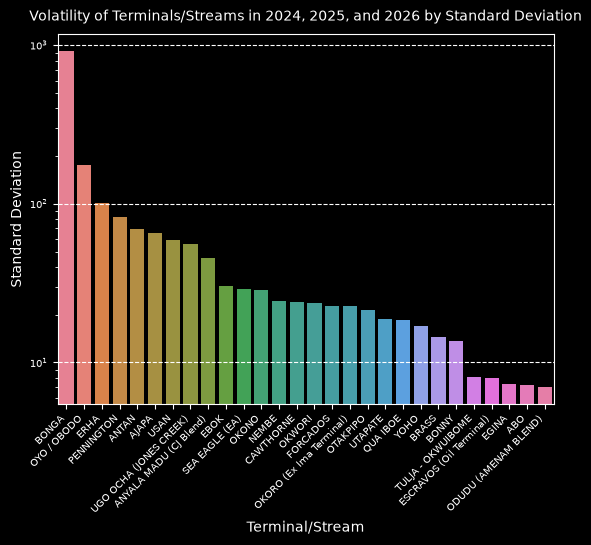

In [120]:
sns.barplot(data=sorted_deviation_df, x="Terminal/Stream", y="Standard Deviation", hue="Terminal/Stream")
plt.title("Volatility of Terminals/Streams in 2024, 2025, and 2026 by Standard Deviation", fontsize=10, pad=10)
plt.yscale("log")
plt.grid(axis="y", linestyle="--")
plt.xticks(rotation=45, ha="right", fontsize=7)
plt.yticks(fontsize=7)
plt.show()

From the chart above, it can be seen that the terminals exhibiting the highest standard deviation values are Bonga, Oyo/Obodo, Erha, Pennington and Antan.

Bonga terminal exhibits an unusually high standard deviation due to a single outlier drop and jump in February 2026 and March 2026. There was a 98% drop between January and February 2026, and a 4900% rise between February and March 2026.

Erha terminal also underwent the same situation between November 2025 and January 2026. It experienced a 79% drop between November and December 2025 a 529% rise between December 2025 and January 2026.

The graph below further explains this.

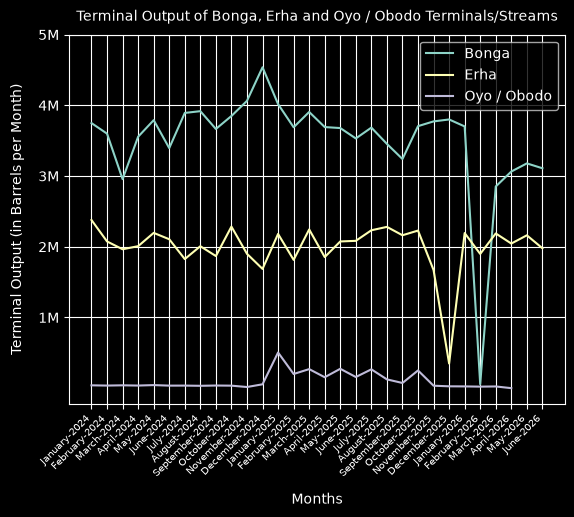

In [121]:
bonga_output_df = q1_master_df.loc[["BONGA"]]
erha_output_df = q1_master_df.loc[["ERHA"]]
oyo_obodo_output_df = q1_master_df.loc[["OYO / OBODO"]]
months = bonga_output_df.columns.tolist()
months.remove('Liquid Type')

plt.title("Terminal Output of Bonga, Erha and Oyo / Obodo Terminals/Streams", fontsize=10, pad=10)
sns.lineplot(x=months, y=bonga_output_df.iloc[0, 1:], label="Bonga")
sns.lineplot(x=months, y=erha_output_df.iloc[0, 1:], label="Erha")
sns.lineplot(x=months, y=oyo_obodo_output_df.iloc[0, 1:], label="Oyo / Obodo")
plt.xlabel("Months", fontsize=10, labelpad=10)
plt.ylabel("Terminal Output (in Barrels per Month)", fontsize=10, labelpad=10)
plt.xticks(rotation=45, ha="right", fontsize=7)
plt.yticks([1000000, 2000000, 3000000, 4000000, 5000000] ,["1M", "2M", "3M", "4M", "5M"])
plt.grid()
plt.show()


The high standard deviation from the production values of the OYO/OBODO terminal is also due to a sudden spike in output values in January 2025.

According to research, OYO/OBODO's combined reporting in the NUPRC monthly data likely bundles two distinct crude streams — Oyo (an established offshore field) and Obodo (a newly launched onshore blend introduced to market in April 2025) — which is consistent with the sharp January 2025 jump, though the exact date NUPRC began combining them under one line isn't independently confirmed.

In February 2026, Shell’s Nigerian upstream subsidiary, SNEPCo, shut down the Bonga FPSO for a scheduled turnaround maintenance programme beginning in February. The work included statutory inspections, certification and regulatory checks, integrity upgrades, and engineering modifications intended to keep the FPSO operating safely and efficiently for the following years. The planned shutdown was expected to remove approximately 225,000 barrels per day of crude production temporarily.

Production restarted on March 6, 2026, after the maintenance was completed 11 days ahead of schedule and without a reported safety incident. That restart explains the sharp March recovery, although March’s monthly total remained below January’s because production was offline for part of the month.

As for the Erha terminal, NNPC’s November 2025 monthly report attributed the production weakness to planned maintenance on several key assets, specifically including Esso-Erha, Stardeep-Agbami, and the Renaissance-Estuary Area. NNPC said those maintenance activities were nearing completion and that production recovery was expected toward the end of December.

That explanation fits the Erha data: the field was already operating below its normal level in November, then recorded an exceptionally low December total. After the maintenance work and associated production initiatives were completed, Erha returned to 2.19 million barrels in January, exceeding its November volume

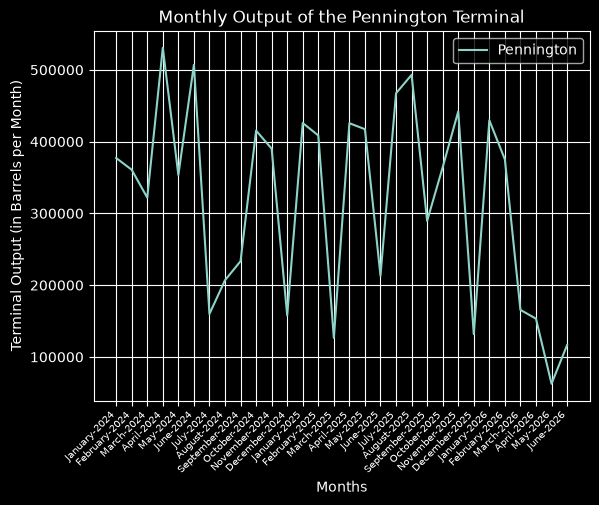

In [122]:
pennington_output_df = q1_master_df.loc[["PENNINGTON"]]

plt.title("Monthly Output of the Pennington Terminal")
sns.lineplot(x=months, y=pennington_output_df.iloc[0, 1:], label="Pennington")
plt.xticks(rotation=45, ha="right", fontsize=7)
plt.ylabel("Terminal Output (in Barrels per Month)")
plt.xlabel("Months")
plt.grid()
plt.show()

The chart above displays the crude oil output values for the Pennington Terminal. The terminals output volatility can be clearly seen here, not influenced by a single major event, it displays highly unstable ouput values across the two-and-a-half year period. This is consistent with Pennington being a mature, depleted asset (OML 88, producing since the 1970s, now a legacy shallow-water block with a small remaining base) — where ordinary operational variance, applied to a small production volume, produces outsized percentage swings on a recurring basis rather than through any one triggering incident.

## Question 1 Conclusion

The Pennington Terminal has been found to have genuine chronic volatility across the 30-month period, driven by its status as a mature, depleted, small-base asset rather than a single outlier event. The Bonga, Erha and Oyo/Obodo terminals also rank highly by raw standard deviation, but each traces to one identifiable event, rather than sustained instability.

The specific month-to-month swings investigated above in the Bonga, Erha and Oyo/Obodo terminals also serve as the answer to which individual changes were most extreme, since these are the same events driving the terminal-level ranking.

NOTE: the Cawthorne terminal's standard deviation values should not be read as directly comparable to terminals with a full 2.5 year history as it only possesses output data for the year 2026.

## Question 2: Overall Output Trend per Terminal (2024-mid 2026)

Methodology:

Average the output values from the first three months and the last three months for each terminal across the 2024 to mid 2026 timeline.

Find the percentage change in these values for each terminal. 

Compare the change values for each terminal with a threshold number t equal to 2 x std_dev of the terminal. A value less than -t is considered an overall decline, while a value greater than +t is considered an overall rise.

In [123]:
sliced_df = q1_master_df.iloc[:, [1, 2, 3, -3, -2, -1]]
sliced_df


,January-2024,February-2024,March-2024,April-2026,May-2026,June-2026
Terminal/Stream,,,,,,
BONNY,6351778.0,4604102.0,4260566.0,8360400.0,8588240.0,9057900.0
BRASS,735680.0,617189.0,686188.0,989700.0,1046870.0,995400.0
QUA IBOE,4251198.0,3664686.0,4058695.0,4918200.0,5371370.0,4892100.0
FORCADOS,7799819.0,6796892.0,6675119.0,6654000.0,8265530.0,8485800.0
ESCRAVOS (Oil Terminal),4178516.0,3684339.0,4012721.0,4070100.0,4128890.0,4053600.0
ODUDU (AMENAM BLEND),2934994.0,2722999.0,2836178.0,1854000.0,1953310.0,1859400.0
TULJA - OKWUIBOME,1762863.0,1732677.0,1859018.0,1595700.0,1655710.0,1626600.0
OKORO (Ex Ima Terminal),203761.0,190965.0,201924.0,114000.0,119660.0,162900.0
OTAKPIPO,278843.0,217705.0,242882.0,255600.0,223510.0,178200.0


In [124]:
#is_null_df = (sliced_df.iloc[:, 0:3].notnull().any(axis=1)) & (sliced_df.iloc[:, -3:].notnull().any(axis=1))
is_null_df = (
    sliced_df.iloc[:, 0:3].notnull().sum(axis=1) >= 2
) & (
    sliced_df.iloc[:, -3:].notnull().sum(axis=1) >= 2
)
is_null_df

Terminal/Stream
BONNY                       True
BRASS                       True
QUA IBOE                    True
FORCADOS                    True
ESCRAVOS (Oil Terminal)     True
ODUDU (AMENAM BLEND)        True
TULJA - OKWUIBOME           True
OKORO (Ex Ima Terminal)     True
OTAKPIPO                    True
ANTAN                       True
OKONO                      False
YOHO                       False
OKWORI                      True
EBOK                        True
AJAPA                       True
BONGA                       True
ERHA                        True
USAN                        True
EGINA                       True
OYO / OBODO                False
ABO                         True
PENNINGTON                  True
UGO OCHA (JONES CREEK)      True
SEA EAGLE (EA)              True
ANYALA MADU (CJ Blend)      True
NEMBE                       True
UTAPATE                    False
CAWTHORNE                  False
dtype: bool

In [125]:
q2_master_df = q1_master_df[is_null_df]
q2_master_df

,Liquid Type,January-2024,February-2024,March-2024,April-2024,May-2024,June-2024,July-2024,August-2024,September-2024,...,September-2025,October-2025,November-2025,December-2025,January-2026,February-2026,March-2026,April-2026,May-2026,June-2026
Terminal/Stream,,,,,,,,,,,,,,,,,,,,,
BONNY,Crude Oil,6351778.0,4604102.0,4260566.0,4158173.0,3605864.0,4536573.0,4584388.0,4894497.0,5589773.0,...,5924385.0,7535315.0,7751499.0,7884015.0,7201300.0,7360640.0,7998000.0,8360400.0,8588240.0,9057900.0
BRASS,Crude Oil,735680.0,617189.0,686188.0,647053.0,635929.0,648849.0,664387.0,718104.0,842900.0,...,935010.0,946439.0,981254.0,914165.0,941160.0,963480.0,1087790.0,989700.0,1046870.0,995400.0
QUA IBOE,Crude Oil,4251198.0,3664686.0,4058695.0,4284484.0,3962759.0,3261367.0,3343465.0,3073804.0,2833479.0,...,4640056.0,2683665.0,3980764.0,5074619.0,4549870.0,4401040.0,5196840.0,4918200.0,5371370.0,4892100.0
FORCADOS,Crude Oil,7799819.0,6796892.0,6675119.0,6289085.0,5927475.0,6160694.0,6813681.0,8126915.0,6341130.0,...,6853852.0,8585208.0,8327198.0,8569954.0,7946850.0,6234760.0,4733080.0,6654000.0,8265530.0,8485800.0
ESCRAVOS (Oil Terminal),Crude Oil,4178516.0,3684339.0,4012721.0,3866374.0,4113862.0,3996696.0,4385991.0,4209219.0,4080483.0,...,4129694.0,4329068.0,3829825.0,4091466.0,4227470.0,3745000.0,4355500.0,4070100.0,4128890.0,4053600.0
ODUDU (AMENAM BLEND),Crude Oil,2934994.0,2722999.0,2836178.0,2659792.0,2630817.0,2572785.0,2468442.0,2583858.0,2462691.0,...,2005854.0,2111519.0,1888702.0,1970777.0,1946800.0,1862840.0,2034840.0,1854000.0,1953310.0,1859400.0
TULJA - OKWUIBOME,Crude Oil,1762863.0,1732677.0,1859018.0,1837364.0,1972551.0,1928150.0,1992021.0,2008090.0,2029787.0,...,1627130.0,1581339.0,1591292.0,1561674.0,1758010.0,1386840.0,1566740.0,1595700.0,1655710.0,1626600.0
OKORO (Ex Ima Terminal),Crude Oil,203761.0,190965.0,201924.0,182645.0,188990.0,167626.0,181758.0,173385.0,167614.0,...,134175.0,147289.0,145562.0,163212.0,154070.0,93800.0,119040.0,114000.0,119660.0,162900.0
OTAKPIPO,Crude Oil,278843.0,217705.0,242882.0,270168.0,306424.0,270141.0,266605.0,197152.0,195878.0,...,206713.0,204048.0,194965.0,199316.0,196230.0,176120.0,263190.0,255600.0,223510.0,178200.0


In [126]:
# first three months output average
start = q2_master_df.iloc[:, 1:4].mean(axis=1)

# last three months output average
end = q2_master_df.iloc[:, -3:].mean(axis=1)

# percentage change in output from first three months to last three months
pct_change = ((end - start) / start) * 100

pct_change

Terminal/Stream
BONNY                       70.910737
BRASS                       48.694715
QUA IBOE                    26.782495
FORCADOS                    10.029697
ESCRAVOS (Oil Terminal)      3.174701
ODUDU (AMENAM BLEND)       -33.287074
TULJA - OKWUIBOME           -8.899857
OKORO (Ex Ima Terminal)    -33.535574
OTAKPIPO                   -11.105852
ANTAN                      -35.672503
OKWORI                     -22.346380
EBOK                       -37.079454
AJAPA                      163.812500
BONGA                       -9.238741
ERHA                        -3.603502
USAN                        -4.445801
EGINA                      -45.957238
ABO                        -31.711202
PENNINGTON                 -68.643318
UGO OCHA (JONES CREEK)      88.135278
SEA EAGLE (EA)             122.385211
ANYALA MADU (CJ Blend)      48.903947
NEMBE                       20.586381
dtype: float64

In [127]:
# extract the standard deviation values for the terminals in q2_master_df from deviation_df
q2_deviation_df = deviation_df.loc[q2_master_df.index]
q2_deviation = q2_deviation_df["Standard Deviation"].squeeze()


trend = pd.Series(index=q2_master_df.index, dtype="object")

# classify the trend of each terminal based on the percentage change and standard deviation
trend[pct_change > 2 * q2_deviation] = "Rising"
trend[pct_change < -2 * q2_deviation] = "Falling"
trend[(pct_change <= 2 * q2_deviation) & (pct_change >= -2 * q2_deviation)] = "Flat"
trend

Terminal/Stream
BONNY                       Rising
BRASS                       Rising
QUA IBOE                      Flat
FORCADOS                      Flat
ESCRAVOS (Oil Terminal)       Flat
ODUDU (AMENAM BLEND)       Falling
TULJA - OKWUIBOME             Flat
OKORO (Ex Ima Terminal)       Flat
OTAKPIPO                      Flat
ANTAN                         Flat
OKWORI                        Flat
EBOK                          Flat
AJAPA                       Rising
BONGA                         Flat
ERHA                          Flat
USAN                          Flat
EGINA                      Falling
ABO                        Falling
PENNINGTON                    Flat
UGO OCHA (JONES CREEK)        Flat
SEA EAGLE (EA)              Rising
ANYALA MADU (CJ Blend)        Flat
NEMBE                         Flat
dtype: object

The terminals are classified using a threshold number that is unique to each terminal. This threshold number is derived by multiplying the standard deviation of each terminal by a number k, which is 2 in this case.

The number 2 was chosen as tests showed that the resulting classifications across 1.5 < k > 2.5 were generally stable.

Please note that "flat" in the classifications above does NOT mean stable. Rather, it implies that a single sharp event was later offset, netting out to roughly zero over the full window despite real, documented disruption in between.

For example, in the case of the Pennington terminal, it means sustained, chronic volatility that never resolved into a clear net direction.

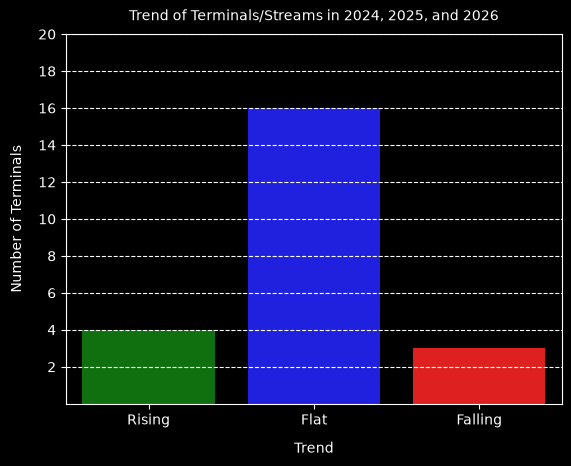

In [128]:
# converts trend series to dataframe named trend_df for visualization
trend_df = trend.to_frame(name="Trend")

sns.countplot(data=trend_df, x="Trend", hue="Trend", palette={"Rising": "green", "Falling": "red", "Flat": "blue"})
plt.title("Trend of Terminals/Streams in 2024, 2025, and 2026", fontsize=10, pad=10)
plt.xlabel("Trend", fontsize=10, labelpad=10)
plt.ylabel("Number of Terminals", fontsize=10, labelpad=10)
plt.yticks([2, 4, 6, 8, 10, 12, 14, 16, 18, 20], ["2", "4", "6", "8", "10", "12", "14", "16", "18", "20"])
plt.grid(axis="y", linestyle="--")
plt.style.use("dark_background")
plt.show()

The bar chart above indicates that there were 4 terminals whose output rose over the 2.5 year period, 16 terminals whose output stayed generally flat over the same period, and 3 terminals whose output fell in said period.

BONNY, BRASS, AJAPA and SEA EAGLE (EA) all classify under rising terminals, while ODUDU (Amenam Blend), EGINA and ABO classify under falling. The rest are flat.

It is noteworthy that the top 5 high volatility terminals as ranked previously in Q1 (BONGA, OYO/OBODO, ERHA, PENNINGTON and ANTAN) all classified as flat. This means that all the intense spikes and falls in output during the window cancelled each other out, leaving the output looking relatively flat over the 2.5 year period. 

It is also interesting to note that the three terminals classified as falling also possess the three lowest standard deviation values. This is because this classification method is far more sensitive to genuine trends in low-volatility terminals, and far less able to detect a trend in high-volatility terminals, because the bar for 'trending' scales with each terminal's own noise level.

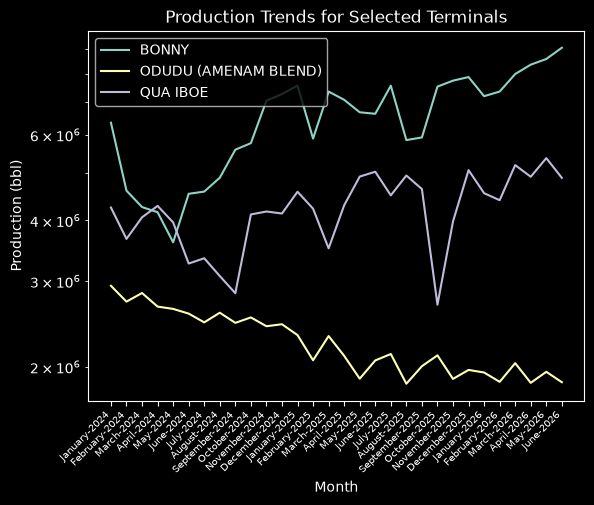

In [129]:
bonny_output_df = q2_master_df.loc[["BONNY"]]
odudu_output_df = q2_master_df.loc[["ODUDU (AMENAM BLEND)"]]
qua_iboe_output_df = q2_master_df.loc[["QUA IBOE"]]

sns.lineplot(x=months, y=bonny_output_df.iloc[0, 1:], label="BONNY")
sns.lineplot(x=months, y=odudu_output_df.iloc[0, 1:], label="ODUDU (AMENAM BLEND)")
sns.lineplot(x=months, y=qua_iboe_output_df.iloc[0, 1:], label="QUA IBOE")

plt.title("Production Trends for Selected Terminals")
plt.xlabel("Month")
plt.xticks(rotation=45, ha="right", fontsize=7)
plt.ylabel("Production (bbl)")
plt.yscale('log')
plt.legend()
plt.style.use('dark_background')
plt.show()

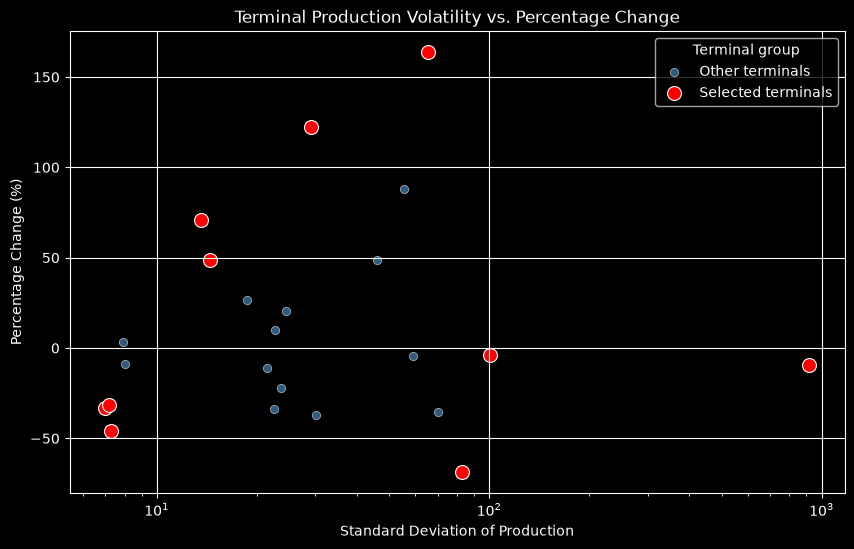

In [130]:
# convert pct_change series to dataframe for visualization
pct_change_df = pct_change.to_frame(name="Percentage Change")
plot_df = pd.concat([pct_change_df, q2_deviation_df], axis=1)

highlight = [
    "BONGA", "BONNY", "BRASS", "PENNINGTON",
    "ERHA", "AJAPA", "SEA EAGLE (EA)", "EGINA", "ABO",
    "ODUDU (AMENAM BLEND)"
]

plot_df["Highlighted"] = plot_df.index.isin(highlight)
highlight_df = plot_df[plot_df["Highlighted"]]
other_df = plot_df[~plot_df["Highlighted"]]

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=other_df,
    x="Standard Deviation",
    y="Percentage Change",
    color="steelblue",
    alpha=0.7,
    label="Other terminals"
)
sns.scatterplot(
    data=highlight_df,
    x="Standard Deviation",
    y="Percentage Change",
    color="red",
    s=100,
    label="Selected terminals"
)

plt.title("Terminal Production Volatility vs. Percentage Change")
plt.xlabel("Standard Deviation of Production")
plt.xscale("log")
plt.ylabel("Percentage Change (%)")
plt.grid()
plt.legend(title="Terminal group")
plt.style.use('dark_background')
plt.show()

The scatter plot above shows the relationship between percentage change and standard deviation. It can be deduced that there is no correlation between the standard deviation of a terminal's output and its percentage change.

The highlighted terminals are "BONGA", "BONNY", "BRASS", "PENNINGTON", "ERHA", "AJAPA", "SEA EAGLE (EA)", "EGINA", "ABO", "ODUDU (AMENAM BLEND)". These are the terminals of particular interest from previous questions.


"YOHO", "CAWTHORNE", 'OYO/OBODO", "UTAPATE" and "OKONO" were filtered out of the Q2 dataset because they did not possess sufficient data.

## Question 2 Conclusion

Majority of the terminals (~70%) in the dataset net flat trends. However, this flat conceals two different stories that can be revealed through the terminal's Standard Deviations. Some terminals like PENNINGTON and BONGA classified as flat trends but were incredibly volatile (as seen by their high std values), however, other terminals like QUA IBOE and ESCRAVOS (Oil Terminal) also classified as flat, but possessed mild volatility.

## Question 3: Highest Producing Terminals (2024 - mid 2026)

In this section, we would see the total output of each terminal in the cleaned dataset.

We would then investigate whether the top 20% of terminals in terms of Crude Oil output account for up to 80% of the total output across all terminals.

In [131]:
q3_master_df = q1_master_df
q3_master_df

,Liquid Type,January-2024,February-2024,March-2024,April-2024,May-2024,June-2024,July-2024,August-2024,September-2024,...,September-2025,October-2025,November-2025,December-2025,January-2026,February-2026,March-2026,April-2026,May-2026,June-2026
Terminal/Stream,,,,,,,,,,,,,,,,,,,,,
BONNY,Crude Oil,6351778.0,4604102.0,4260566.0,4158173.0,3605864.0,4536573.0,4584388.0,4894497.0,5589773.0,...,5924385.0,7535315.0,7751499.0,7884015.0,7201300.0,7360640.0,7998000.0,8360400.0,8588240.0,9057900.0
BRASS,Crude Oil,735680.0,617189.0,686188.0,647053.0,635929.0,648849.0,664387.0,718104.0,842900.0,...,935010.0,946439.0,981254.0,914165.0,941160.0,963480.0,1087790.0,989700.0,1046870.0,995400.0
QUA IBOE,Crude Oil,4251198.0,3664686.0,4058695.0,4284484.0,3962759.0,3261367.0,3343465.0,3073804.0,2833479.0,...,4640056.0,2683665.0,3980764.0,5074619.0,4549870.0,4401040.0,5196840.0,4918200.0,5371370.0,4892100.0
FORCADOS,Crude Oil,7799819.0,6796892.0,6675119.0,6289085.0,5927475.0,6160694.0,6813681.0,8126915.0,6341130.0,...,6853852.0,8585208.0,8327198.0,8569954.0,7946850.0,6234760.0,4733080.0,6654000.0,8265530.0,8485800.0
ESCRAVOS (Oil Terminal),Crude Oil,4178516.0,3684339.0,4012721.0,3866374.0,4113862.0,3996696.0,4385991.0,4209219.0,4080483.0,...,4129694.0,4329068.0,3829825.0,4091466.0,4227470.0,3745000.0,4355500.0,4070100.0,4128890.0,4053600.0
ODUDU (AMENAM BLEND),Crude Oil,2934994.0,2722999.0,2836178.0,2659792.0,2630817.0,2572785.0,2468442.0,2583858.0,2462691.0,...,2005854.0,2111519.0,1888702.0,1970777.0,1946800.0,1862840.0,2034840.0,1854000.0,1953310.0,1859400.0
TULJA - OKWUIBOME,Crude Oil,1762863.0,1732677.0,1859018.0,1837364.0,1972551.0,1928150.0,1992021.0,2008090.0,2029787.0,...,1627130.0,1581339.0,1591292.0,1561674.0,1758010.0,1386840.0,1566740.0,1595700.0,1655710.0,1626600.0
OKORO (Ex Ima Terminal),Crude Oil,203761.0,190965.0,201924.0,182645.0,188990.0,167626.0,181758.0,173385.0,167614.0,...,134175.0,147289.0,145562.0,163212.0,154070.0,93800.0,119040.0,114000.0,119660.0,162900.0
OTAKPIPO,Crude Oil,278843.0,217705.0,242882.0,270168.0,306424.0,270141.0,266605.0,197152.0,195878.0,...,206713.0,204048.0,194965.0,199316.0,196230.0,176120.0,263190.0,255600.0,223510.0,178200.0


In [132]:
q3_total_output_df = q3_master_df.iloc[:, 1:].sum(axis=1).to_frame(name="Total Output")
q3_total_output_df

,Total Output
Terminal/Stream,
BONNY,194958126.0
BRASS,24908011.0
QUA IBOE,126878715.0
FORCADOS,215988740.0
ESCRAVOS (Oil Terminal),122794953.0
ODUDU (AMENAM BLEND),67488021.0
TULJA - OKWUIBOME,56327553.0
OKORO (Ex Ima Terminal),4673370.0
OTAKPIPO,6259745.0


In [133]:
q3_sorted_output_df = q3_total_output_df.sort_values(ascending=False, by="Total Output")
q3_sorted_output_df

,Total Output
Terminal/Stream,
FORCADOS,215988740.0
BONNY,194958126.0
QUA IBOE,126878715.0
ESCRAVOS (Oil Terminal),122794953.0
BONGA,105104097.0
ODUDU (AMENAM BLEND),67488021.0
EGINA,61391645.0
ERHA,59940395.0
TULJA - OKWUIBOME,56327553.0


In [134]:
total_output_sum = int(q3_sorted_output_df.sum().sum())
print(f"Total Crude Oil output across all terminals: {total_output_sum:,} barrels")

# There are a total of 28 terminals/streams in the dataset.
# 20% of this is 5.6, approximated to 6 terminals/streams.
# We check for the output total of these six terminals, and see what percentage of the total output it represents.

output_top_twenty = int(q3_sorted_output_df.iloc[:6].sum().sum())
print(f"Total Crude Oil output from top 6 terminals/streams: {output_top_twenty:,} barrels")

Total Crude Oil output across all terminals: 1,284,350,529 barrels
Total Crude Oil output from top 6 terminals/streams: 833,212,652 barrels


In [135]:
total_output = 1_284_350_529
threshold_output = total_output * 0.80

cumulative_output = q3_sorted_output_df["Total Output"].cumsum()
terminals_needed = int((cumulative_output < threshold_output).sum() + 1)
output_reached = cumulative_output.iloc[terminals_needed - 1]

print(f"Terminals needed: {terminals_needed}")
print(f"Output reached: {output_reached:,.0f} barrels")

Terminals needed: 10
Output reached: 1,053,123,251 barrels
